<a href="https://colab.research.google.com/github/Ravravan/ML/blob/main/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from sklearn.datasets import make_regression
import numpy as np

In [26]:
x,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

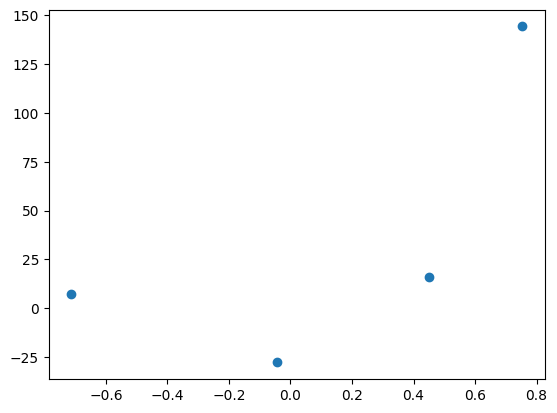

In [27]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [28]:
#apply OLS
from sklearn.linear_model import LinearRegression

In [29]:
reg = LinearRegression()
reg.fit(x,y)

LinearRegression()

In [30]:
reg.coef_

array([78.35063668])

In [31]:
reg.intercept_

np.float64(26.15963284313262)

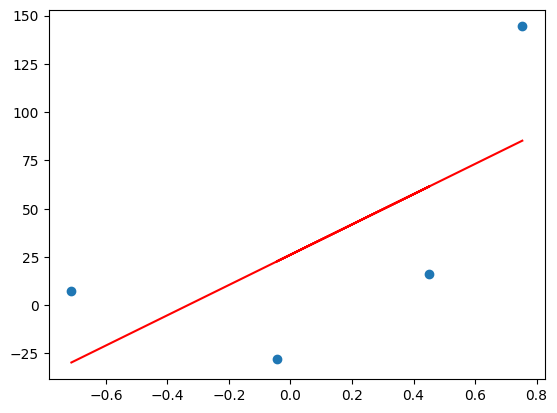

In [32]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red')

In [33]:
#lets apply gradient desent assumig slope is constant = 78.35
# and lets assume the starting value for intercept b = 0
y_pred = ((78.35 * x) + 0).reshape(4)


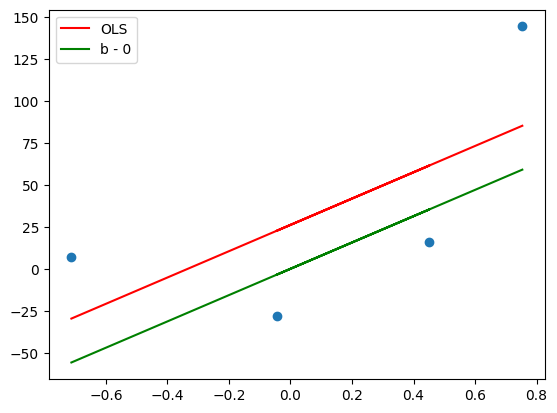

In [34]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x), color='red', label='OLS')
plt.plot(x,y_pred, color='green', label='b - 0')
plt.legend()
plt.show()

In [35]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-209.27763408209216)

In [36]:
#lets take  learning rate = 0.1
lr = 0.1
step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [37]:
#calculating the new intercept
b = b - step_size
b

np.float64(20.927763408209216)

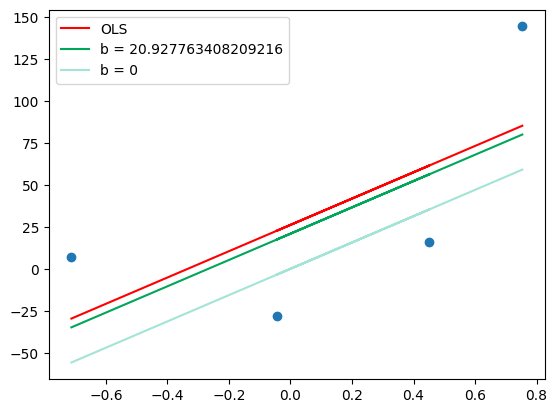

In [38]:
y_pred1 = ((78.35 * x) + b).reshape(4)
plt.scatter(x,y)
plt.plot(x,reg.predict(x), color='red', label='OLS')
plt.plot(x, y_pred1, color='#00a65a', label='b = {}'.format(b))
plt.plot(x,y_pred, color='#A3E4D7', label='b = 0')
plt.legend()
plt.show()


In [39]:
#iteration 2
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-41.85552681641843)

In [40]:
step_size = loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [41]:
b = b - step_size
b

np.float64(25.11331608985106)

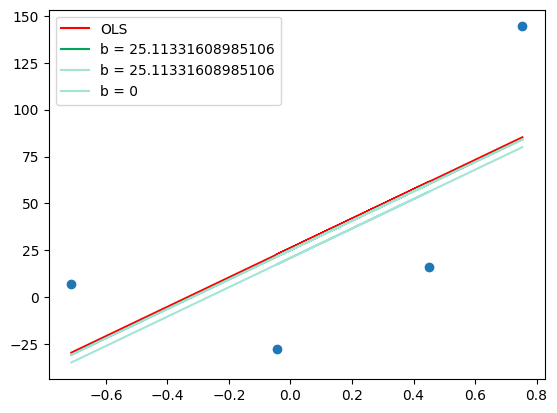

In [42]:
y_pred2 = ((78.35 * x) + b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x), color='red', label='OLS')
plt.plot(x,y_pred2, color='#00a65a', label='b = {}'. format(b))
plt.plot(x,y_pred1, color='#A3E4D7', label='b = {}'. format(b))
plt.plot(x,y_pred2, color='#A3E4D7', label='b = 0')
plt.legend()
plt.show()

In [43]:
#iteration 3
loss_slope = -2 * np.sum(y  - m*x.ravel() -b)

In [44]:
loss_slope

np.float64(-8.371105363283675)

In [45]:
loss_size = loss_slope*lr
loss_size

np.float64(-0.8371105363283675)

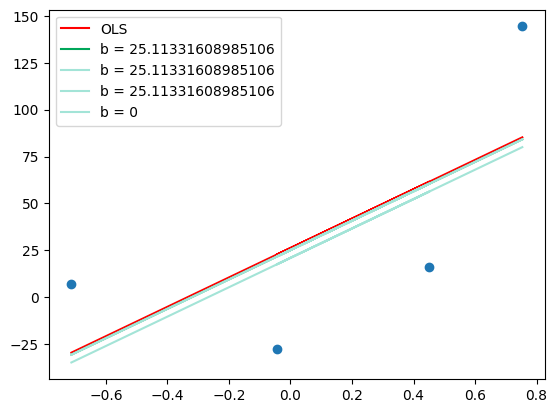

In [23]:
y_pred3 = ((78.35 * x) + b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x), color='red', label='OLS')
plt.plot(x,y_pred3, color='#00a65a', label='b = {}'. format(b))
plt.plot(x,y_pred2, color='#A3E4D7', label='b = {}'. format(b))
plt.plot(x,y_pred1, color='#A3E4D7', label='b = {}'. format(b))
plt.plot(x,y_pred2, color='#A3E4D7', label='b = 0')
plt.legend()
plt.show()

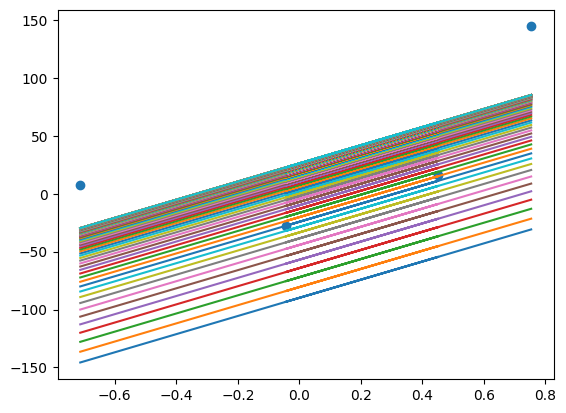

In [48]:

b = -100
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*x.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * x + b

  plt.plot(x,y_pred)

plt.scatter(x,y)

#creating own class

In [49]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score


In [51]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

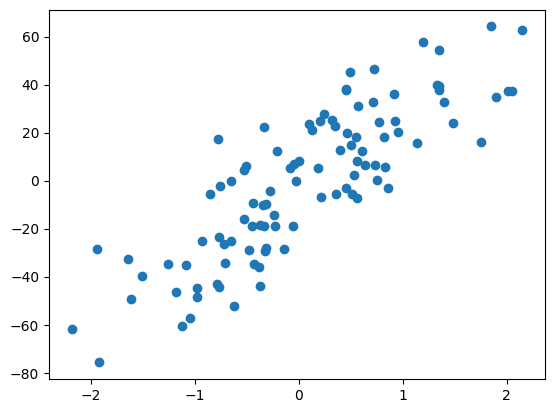

In [52]:
plt.scatter(x,y)

In [53]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [54]:
from sklearn.linear_model import LinearRegression

In [55]:
lr = LinearRegression()

In [56]:
lr.fit(x_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [57]:
y_pred = lr.predict(x_test)
from sklearn.metrics import r2_score

In [58]:
r2_score(y_test, y_pred)

0.6345158782661012

In [65]:
class GDRegressor:

  def __init__(self, learning_rate,epochs):
    self.m = 100
    self.b = -120
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self,x,y):
    #calcualting  b using GD
    for i in range(self.epochs):
      loss_slope_b = -2 * np.sum(y -self.m*x.ravel() - self.b)
      loss_slope_m = -2 * np.sum((y - self.m*x.ravel()  - self.b)*x.ravel())

      self.b = self.b - (self.lr * loss_slope_b)
      self.m  = self.m - (self.lr * loss_slope_m)
    print(self.m, self.b)


  def predict(self, x):
    return self.m * x + self.b

In [66]:
gd = GDRegressor(0.001,50)

In [67]:
gd.fit(x_train, y_train)

28.159367347119066 -2.3004574196824854


In [69]:
y_pred = gd.predict(x_test)
from sklearn.metrics import r2_score

In [70]:
r2_score(y_test, y_pred)

0.6343842836315579